In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")


Libraries imported successfully


In [2]:
# Load all datasets
fund_master = pd.read_csv('../Data/Processed/01_fund_master.csv')
aum_by_fund_house = pd.read_csv('../Data/Processed/03_aum_by_fund_house.csv')
category_inflows = pd.read_csv('../Data/Processed/05_category_inflows.csv')
folio_count = pd.read_csv('../Data/Processed/06_industry_folio_count.csv')
portfolio_holdings = pd.read_csv('../Data/Processed/09_portfolio_holdings.csv')
nav_history = pd.read_csv('../Data/Processed/nav_history_clean.csv')
sip_inflows = pd.read_csv('../Data/Processed/monthly_sip_inflows_clean.csv')
investor_transactions = pd.read_csv('../Data/Processed/investor_transactions_clean.csv')

print("All datasets loaded")
print(f"nav_history: {nav_history.shape}")
print(f"investor_transactions: {investor_transactions.shape}")

All datasets loaded
nav_history: (64320, 3)
investor_transactions: (32778, 13)


In [3]:
# Convert date column to datetime
nav_history['date'] = pd.to_datetime(nav_history['date'])

# Merge scheme names into nav_history using amfi_code
nav_history = nav_history.merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house']],
    on='amfi_code',
    how='left'
)

# Check the actual date range in our data
print("Date range:", nav_history['date'].min(), "to", nav_history['date'].max())
print("Number of unique schemes:", nav_history['amfi_code'].nunique())
nav_history.head()

Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
Number of unique schemes: 40


,date,amfi_code,nav,scheme_name,fund_house
0,2022-01-03,100016,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,2022-01-04,100016,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
2,2022-01-05,100016,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
3,2022-01-06,100016,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
4,2022-01-07,100016,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund


In [4]:
fig1 = px.line(
    nav_history,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend — All 40 Schemes (2022–2026)',
    labels={'nav': 'NAV (₹)', 'date': 'Date', 'scheme_name': 'Scheme'}
)

# Highlight 2023 bull run (label near top)
fig1.add_vrect(
    x0='2023-01-01', x1='2023-12-31',
    fillcolor='green', opacity=0.1, line_width=0,
    annotation_text='2023 Bull Run', annotation_position='top left',
    annotation=dict(yshift=10, font=dict(size=11, color='green'))
)

# Highlight 2024 market correction (label shifted lower so it doesn't clash)
fig1.add_vrect(
    x0='2024-06-01', x1='2024-10-31',
    fillcolor='red', opacity=0.1, line_width=0,
    annotation_text='2024 Correction', annotation_position='top left',
    annotation=dict(yshift=-20, font=dict(size=11, color='red'))
)

fig1.update_layout(
    height=700,
    width=1100,
    legend=dict(
        font=dict(size=7),
        orientation='v',
        yanchor='top', y=1,
        xanchor='left', x=1.02
    ),
    margin=dict(r=250)
)
fig1.show()

### Insight 1: NAV Trend Analysis
Equity fund NAVs show sustained growth through the 2023 bull run, with mid-cap and small-cap schemes posting the steepest gains, while the 2024 correction period shows a visible but temporary flattening across most equity schemes before resuming their upward trajectory into 2026.  
*Supporting chart: `01_nav_trend.png`*

In [5]:
import os

# Make sure reports folder exists
os.makedirs('../reports/charts', exist_ok=True)

try:
    fig1.write_image('../reports/charts/01_nav_trend.png', width=1400, height=700, scale=2)
    print("Saved: 01_nav_trend.png")
except Exception as e:
    print("Error saving PNG:", e)

Saved: 01_nav_trend.png


In [6]:
print(aum_by_fund_house['date'].unique())

<StringArray>
['2022-03-31', '2022-09-30', '2023-03-31', '2023-09-30', '2024-03-31',
 '2024-09-30', '2024-12-31', '2025-03-31', '2025-12-31']
Length: 9, dtype: str


In [7]:
# Convert date to datetime and extract year
aum_by_fund_house['date'] = pd.to_datetime(aum_by_fund_house['date'])
aum_by_fund_house['year'] = aum_by_fund_house['date'].dt.year

# For each fund house and year, keep only the latest snapshot in that year
aum_yearly = aum_by_fund_house.sort_values('date').groupby(['fund_house', 'year']).tail(1)

# Keep only 2022-2025 as per task requirement
aum_yearly = aum_yearly[aum_yearly['year'].between(2022, 2025)]

print(aum_yearly[['year', 'fund_house', 'aum_crore']].sort_values(['year', 'aum_crore'], ascending=[True, False]).head(15))

    year                fund_house  aum_crore
10  2022           SBI Mutual Fund     630000
11  2022       ICICI Prudential MF     488000
12  2022          HDFC Mutual Fund     445000
15  2022  Aditya Birla Sun Life MF     285000
13  2022           Nippon India MF     278000
14  2022         Kotak Mahindra MF     272000
16  2022          Axis Mutual Fund     240000
17  2022           UTI Mutual Fund     232000
19  2022           DSP Mutual Fund     112000
18  2022            Mirae Asset MF     108000
30  2023           SBI Mutual Fund     845000
31  2023       ICICI Prudential MF     590000
32  2023          HDFC Mutual Fund     535000
33  2023           Nippon India MF     340000
34  2023         Kotak Mahindra MF     325000


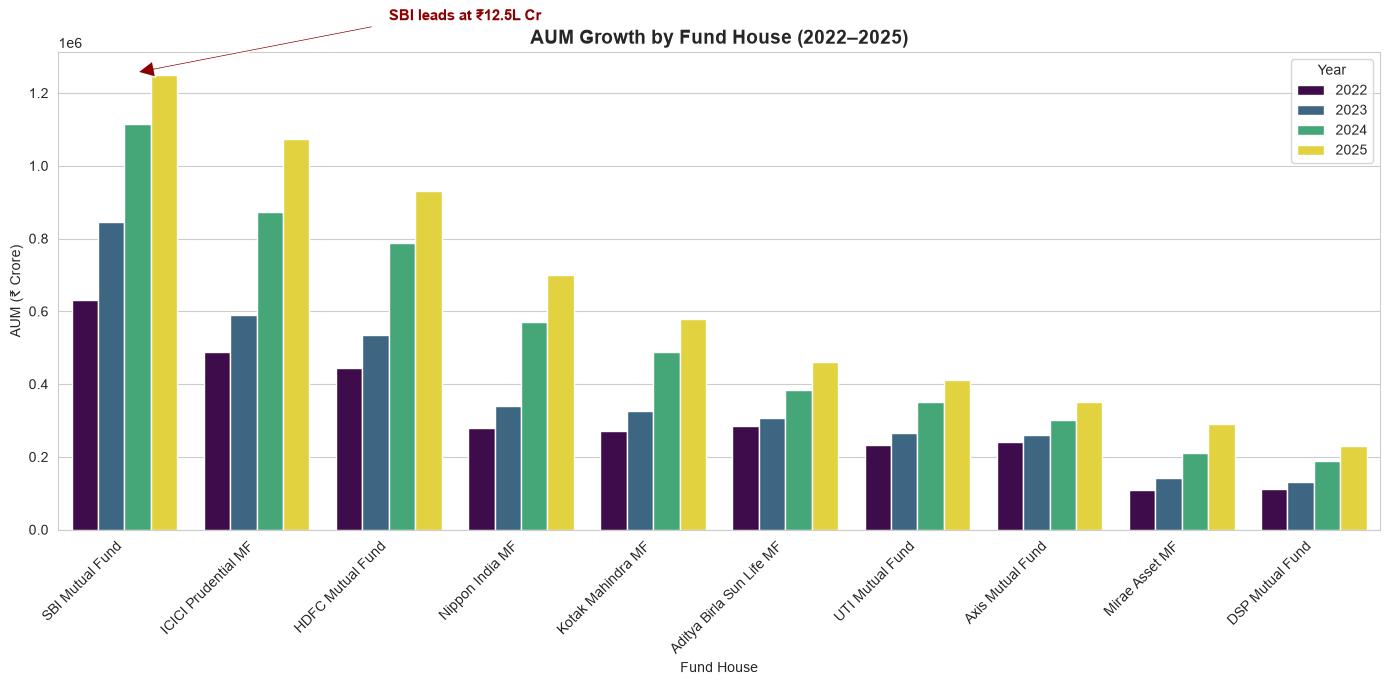

In [8]:
plt.figure(figsize=(14, 7))

# Order fund houses by their 2025 AUM (largest to smallest) for a clean visual story
order = aum_yearly[aum_yearly['year'] == 2025].sort_values('aum_crore', ascending=False)['fund_house']

ax = sns.barplot(
    data=aum_yearly,
    x='fund_house',
    y='aum_crore',
    hue='year',
    order=order,
    palette='viridis'
)

plt.title('AUM Growth by Fund House (2022–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Fund House')
plt.ylabel('AUM (₹ Crore)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')

# Highlight SBI's dominance
sbi_2025 = aum_yearly[(aum_yearly['fund_house'] == 'SBI Mutual Fund') & (aum_yearly['year'] == 2025)]['aum_crore'].values[0]
plt.annotate(
    f'SBI leads at ₹{sbi_2025/100000:.1f}L Cr',
    xy=(0, sbi_2025), xytext=(2, sbi_2025 + 150000),
    fontsize=11, fontweight='bold', color='darkred',
    arrowprops=dict(facecolor='darkred', shrink=0.05, width=1.5)
)

plt.tight_layout()
plt.savefig('../reports/charts/02_aum_growth.png', dpi=200, bbox_inches='tight')
plt.show()

### Insight 2: AUM Growth by Fund House
SBI Mutual Fund maintains clear market leadership across all four years, growing from ₹6.3L Cr in 2022 to ₹12.5L Cr in 2025, roughly double the AUM of its nearest competitor, ICICI Prudential MF.  
*Supporting chart: `02_aum_growth.png`*

In [9]:
sip_inflows['month'] = pd.to_datetime(sip_inflows['month'])
print(sip_inflows[['month', 'sip_inflow_crore']].sort_values('sip_inflow_crore', ascending=False).head(5))
print()
print("Date range:", sip_inflows['month'].min(), "to", sip_inflows['month'].max())

        month  sip_inflow_crore
47 2025-12-01             31002
46 2025-11-01             30200
45 2025-10-01             29529
44 2025-09-01             29361
42 2025-07-01             28464

Date range: 2022-01-01 00:00:00 to 2025-12-01 00:00:00


In [28]:
fig3 = px.line(
    sip_inflows,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)',
    labels={'sip_inflow_crore': 'SIP Inflow (₹ Crore)', 'month': 'Month'},
    markers=True
)

fig3.update_traces(line=dict(color='#1f77b4', width=2.5))

peak = sip_inflows.loc[sip_inflows['sip_inflow_crore'].idxmax()]

fig3.add_annotation(
    x=str(peak['month'].date()), y=peak['sip_inflow_crore'],
    text=f"All-time high: ₹{peak['sip_inflow_crore']:,.0f} Cr (Dec 2025)",
    showarrow=True, arrowhead=2, arrowcolor='darkred',
    ax=-100, ay=-50,
    font=dict(size=12, color='darkred', family='Arial Black'),
    bgcolor='white', bordercolor='darkred', borderwidth=1
)

fig3.update_layout(height=600, width=1100)
fig3.show()

fig3.write_image('../reports/charts/03_sip_inflow_trend.png', width=1400, height=700, scale=2)
print("Saved: 03_sip_inflow_trend.png")

Saved: 03_sip_inflow_trend.png


### Insight 3: SIP Inflow Trend
Monthly SIP inflows have grown almost every month since Jan 2022, culminating in an all-time high of ₹31,002 Cr in Dec 2025, reflecting steadily rising retail investor participation through systematic investing.  
*Supporting chart: `03_sip_inflow_trend.png`*

In [11]:
category_inflows['month'] = pd.to_datetime(category_inflows['month'])
print(category_inflows['category'].unique())
print()
print(category_inflows.head())

<StringArray>
[        'Large Cap',           'Mid Cap',         'Small Cap',
         'Flexi Cap',   'Large & Mid Cap',              'ELSS',
      'Value/Contra', 'Sectoral/Thematic',            'Liquid',
    'Short Duration',              'Gilt',            'Hybrid']
Length: 12, dtype: str

       month         category  net_inflow_crore
0 2024-04-01        Large Cap            2413.0
1 2024-04-01          Mid Cap            3897.0
2 2024-04-01        Small Cap            3533.0
3 2024-04-01        Flexi Cap            4947.0
4 2024-04-01  Large & Mid Cap            4214.0


Date range: 2024-04-01 00:00:00 to 2025-03-01 00:00:00


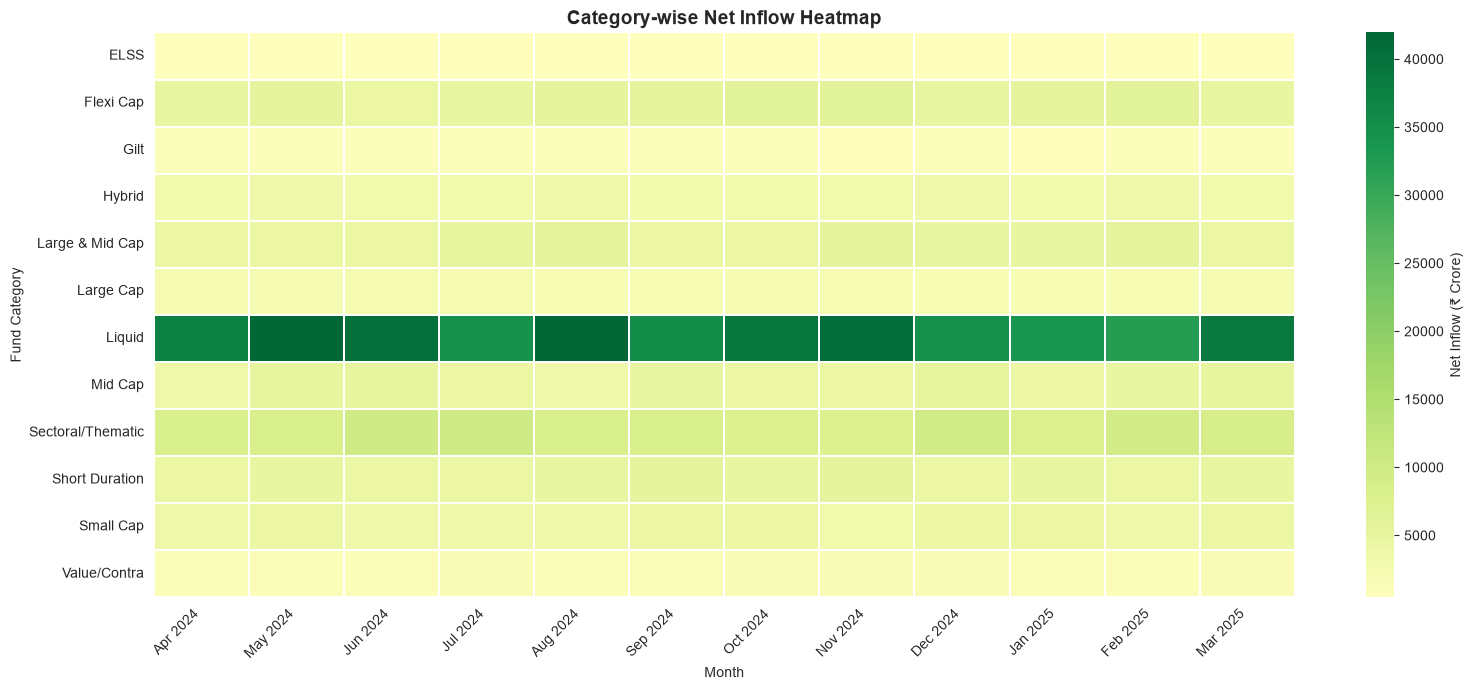

In [12]:
print("Date range:", category_inflows['month'].min(), "to", category_inflows['month'].max())

# Pivot: months as columns, categories as rows, net_inflow_crore as values
heatmap_data = category_inflows.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(16, 7))
ax = sns.heatmap(
    heatmap_data,
    cmap='RdYlGn',
    center=0,
    annot=False,
    linewidths=0.3,
    cbar_kws={'label': 'Net Inflow (₹ Crore)'}
)

# Format x-axis labels to show as "Jan 2024" instead of full timestamps
ax.set_xticklabels([pd.to_datetime(t.get_text()).strftime('%b %Y') for t in ax.get_xticklabels()], rotation=45, ha='right')

plt.title('Category-wise Net Inflow Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.tight_layout()
plt.savefig('../reports/charts/04_category_inflow_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

### Insight 4: Category-wise Inflow Patterns
Liquid funds dominate net inflows in absolute terms across nearly every month, while the normalized view reveals that smaller categories like Sectoral/Thematic and Small Cap show their own distinct high and low months, indicating category-specific investor sentiment shifts.  
*Supporting charts: `04_category_inflow_heatmap.png`, `04b_category_inflow_heatmap_normalized.png`*

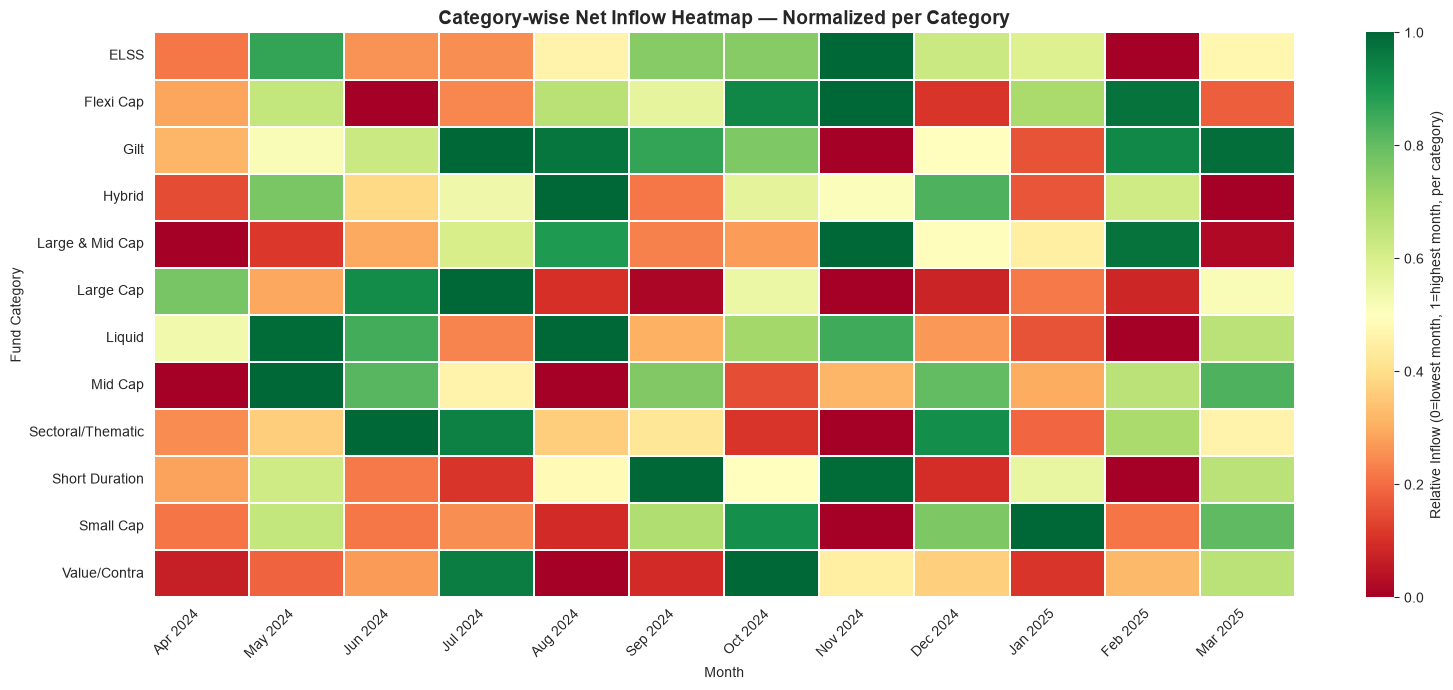

In [14]:
# Manually normalize each row (category) to a 0-1 scale
heatmap_normalized = heatmap_data.sub(heatmap_data.min(axis=1), axis=0).div(
    heatmap_data.max(axis=1) - heatmap_data.min(axis=1), axis=0
)

plt.figure(figsize=(16, 7))
ax2 = sns.heatmap(
    heatmap_normalized,
    cmap='RdYlGn',
    annot=False,
    linewidths=0.3,
    cbar_kws={'label': 'Relative Inflow (0=lowest month, 1=highest month, per category)'}
)

ax2.set_xticklabels([pd.to_datetime(t.get_text()).strftime('%b %Y') for t in ax2.get_xticklabels()], rotation=45, ha='right')

plt.title('Category-wise Net Inflow Heatmap — Normalized per Category', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.tight_layout()
plt.savefig('../reports/charts/04b_category_inflow_heatmap_normalized.png', dpi=200, bbox_inches='tight')
plt.show()

### Insight 5: Investor Demographics
Investors aged 26-35 make up the largest share of the investor base (41.1%), and while median SIP amounts are broadly similar across age groups, all groups show high-value outlier investors contributing SIPs above ₹40,000; the investor base skews male (66.5%) versus female (33.5%).  
*Supporting chart: `05_investor_demographics.png`*

In [15]:
print("Age groups:", investor_transactions['age_group'].unique())
print("Gender:", investor_transactions['gender'].unique())
print("Transaction types:", investor_transactions['transaction_type'].unique())

Age groups: <StringArray>
['56+', '18-25', '36-45', '26-35', '46-55']
Length: 5, dtype: str
Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Transaction types: <StringArray>
['Sip', 'Redemption', 'Lumpsum']
Length: 3, dtype: str


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9732\2548729940.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sip_only, x='age_group', y='amount_inr', order=age_order, ax=axes[1], palette='viridis')


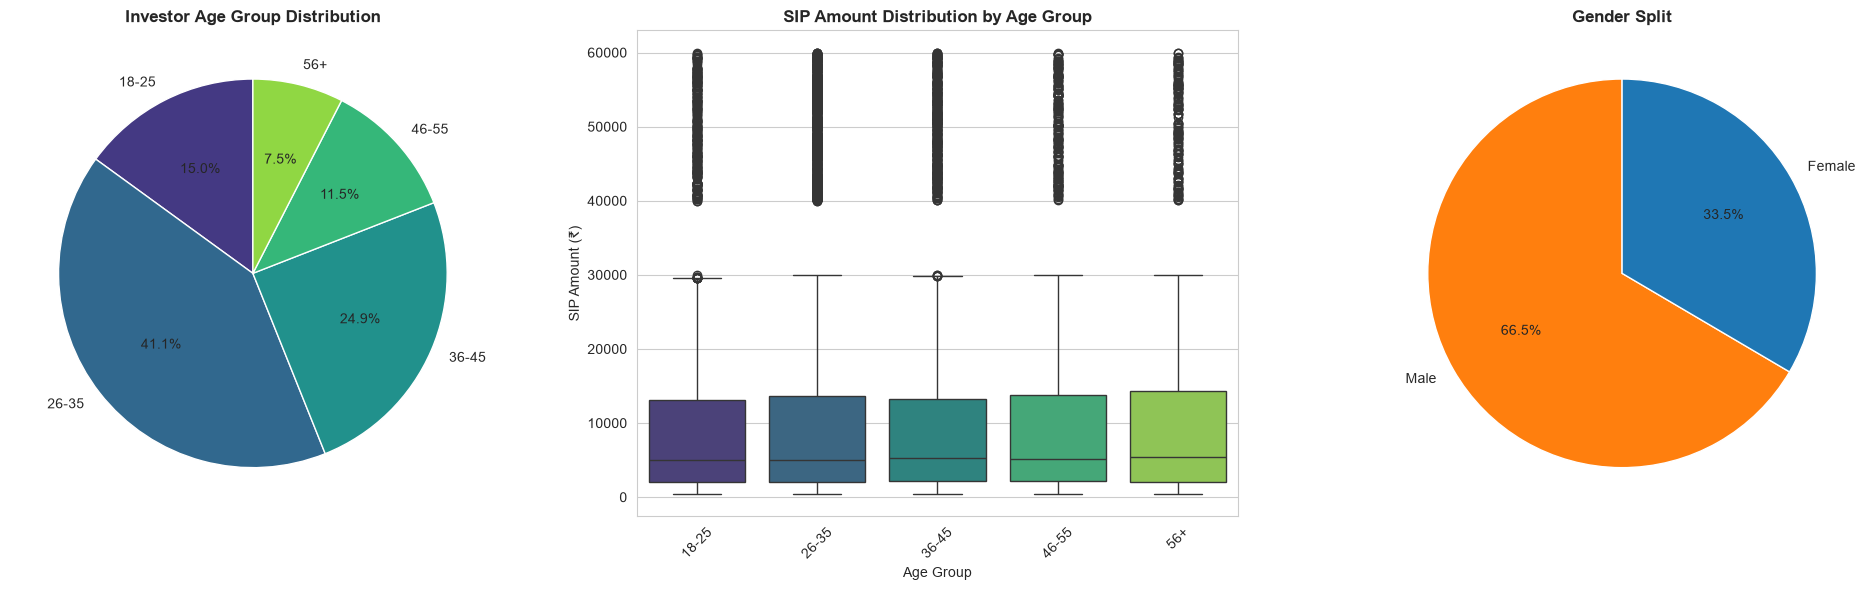

In [16]:
age_order = ['18-25', '26-35', '36-45', '46-55', '56+']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Age group distribution pie chart
age_counts = investor_transactions['age_group'].value_counts().reindex(age_order)
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('viridis', 5))
axes[0].set_title('Investor Age Group Distribution', fontweight='bold')

# Chart 2: SIP amount box plot by age group
sip_only = investor_transactions[investor_transactions['transaction_type'] == 'Sip']
sns.boxplot(data=sip_only, x='age_group', y='amount_inr', order=age_order, ax=axes[1], palette='viridis')
axes[1].set_title('SIP Amount Distribution by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (₹)')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3: Gender split
gender_counts = investor_transactions['gender'].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#ff7f0e', '#1f77b4'])
axes[2].set_title('Gender Split', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/charts/05_investor_demographics.png', dpi=200, bbox_inches='tight')
plt.show()

### Insight 6: Geographic Distribution
SIP contributions are led by Madhya Pradesh and Punjab among the states studied, and T30 (top 30) cities account for roughly two-thirds (66.3%) of SIP amounts, confirming that metro and large urban centers still dominate mutual fund participation over B30 regions.  
*Supporting chart: `06_geographic_distribution.png`*

In [17]:
print("Number of unique states:", investor_transactions['state'].nunique())
print(investor_transactions['state'].unique())
print()
print("City tier values:", investor_transactions['city_tier'].unique())

Number of unique states: 12
<StringArray>
[     'Telangana',         'Punjab',        'Haryana',    'Maharashtra',
          'Delhi', 'Madhya Pradesh',        'Gujarat',      'Rajasthan',
  'Uttar Pradesh',      'Karnataka',    'West Bengal',     'Tamil Nadu']
Length: 12, dtype: str

City tier values: <StringArray>
['T30', 'B30']
Length: 2, dtype: str


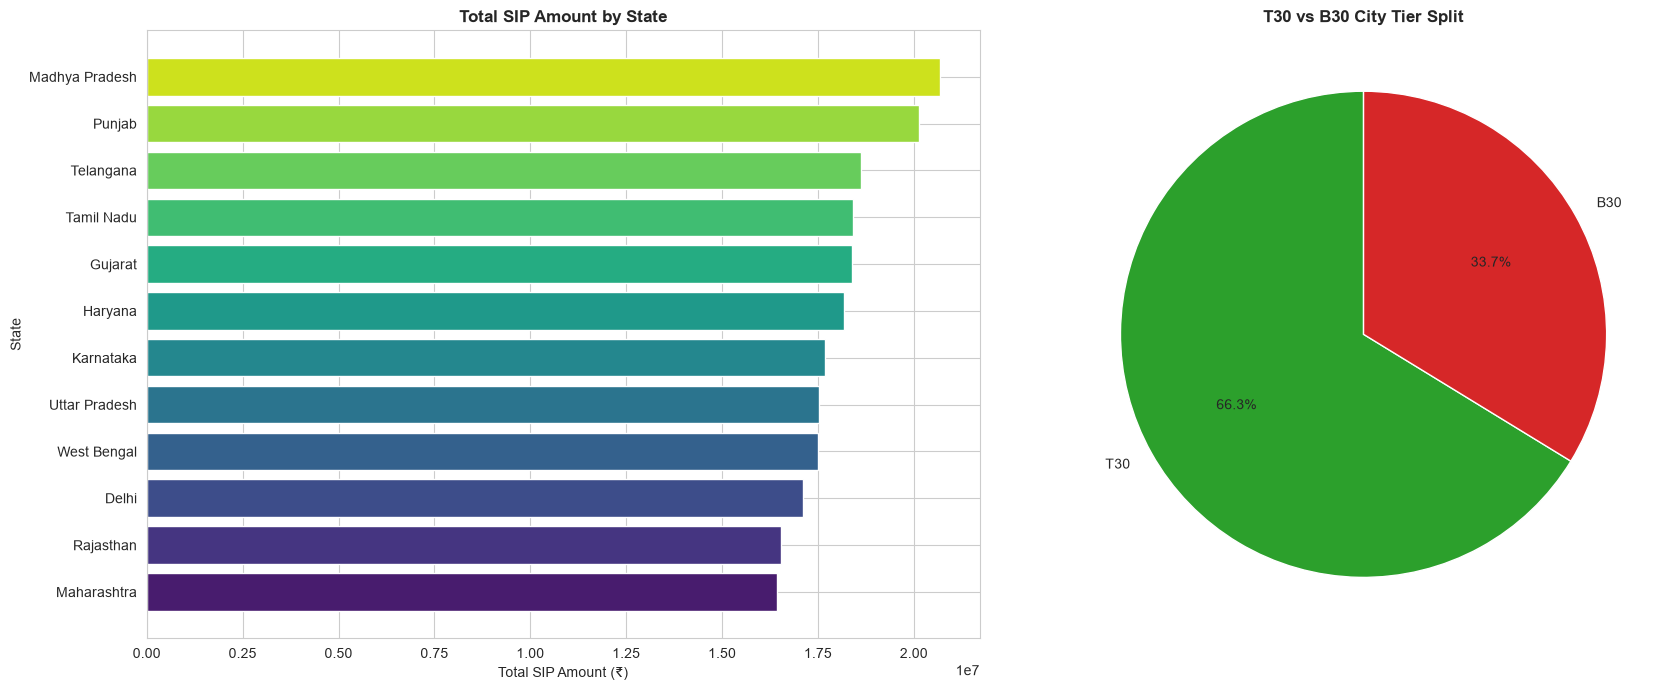

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1: Horizontal bar chart of SIP amount by state
sip_by_state = sip_only.groupby('state')['amount_inr'].sum().sort_values(ascending=True)
axes[0].barh(sip_by_state.index, sip_by_state.values, color=sns.color_palette('viridis', len(sip_by_state)))
axes[0].set_title('Total SIP Amount by State', fontweight='bold')
axes[0].set_xlabel('Total SIP Amount (₹)')
axes[0].set_ylabel('State')

# Chart 2: T30 vs B30 pie chart
tier_counts = investor_transactions['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#2ca02c', '#d62728'])
axes[1].set_title('T30 vs B30 City Tier Split', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/charts/06_geographic_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

### Insight 6: Geographic Distribution
SIP contributions are led by Madhya Pradesh and Punjab among the states studied, and T30 (top 30) cities account for roughly two-thirds (66.3%) of SIP amounts, confirming that metro and large urban centers still dominate mutual fund participation over B30 regions.  
*Supporting chart: `06_geographic_distribution.png`*

In [19]:
folio_count['month'] = pd.to_datetime(folio_count['month'])
print(folio_count.head())
print()
print("Date range:", folio_count['month'].min(), "to", folio_count['month'].max())
print("First value:", folio_count['total_folios_crore'].iloc[0])
print("Last value:", folio_count['total_folios_crore'].iloc[-1])

       month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0 2022-01-01               13.26                 9.28               1.86   
1 2022-04-01               13.91                 9.74               1.95   
2 2022-07-01               13.85                 9.69               1.94   
3 2022-10-01               14.12                 9.88               1.98   
4 2023-01-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  

Date range: 2022-01-01 00:00:00 to 2025-12-01 00:00:00
First value: 13.26
Last value: 26.12


In [21]:
fig7 = px.line(
    folio_count,
    x='month',
    y='total_folios_crore',
    title='Total Folio Count Growth (Jan 2022 – Dec 2025)',
    labels={'total_folios_crore': 'Total Folios (Crore)', 'month': 'Month'},
    markers=True
)
fig7.update_traces(line=dict(color='#2ca02c', width=2.5))

# Mark start and end points (convert Timestamp to string for annotation compatibility)
fig7.add_annotation(x=str(folio_count['month'].iloc[0].date()), y=folio_count['total_folios_crore'].iloc[0],
    text='13.26 Cr (Jan 2022)', showarrow=True, arrowhead=2, ax=0, ay=-40)
fig7.add_annotation(x=str(folio_count['month'].iloc[-1].date()), y=folio_count['total_folios_crore'].iloc[-1],
    text='26.12 Cr (Dec 2025)', showarrow=True, arrowhead=2, ax=0, ay=-40)

# Mark the 20 Cr crossing milestone
crossing_20 = folio_count[folio_count['total_folios_crore'] >= 20].iloc[0]
fig7.add_annotation(x=str(crossing_20['month'].date()), y=crossing_20['total_folios_crore'],
    text='Crossed 20 Cr folios', showarrow=True, arrowhead=2, ax=40, ay=-40, font=dict(color='darkorange'))

fig7.update_layout(height=600, width=1100)
fig7.show()
fig7.write_image('../reports/charts/07_folio_growth.png', width=1400, height=700, scale=2)
print("Saved: 07_folio_growth.png")

Saved: 07_folio_growth.png


### Insight 7: Folio Count Growth
Total investor folios nearly doubled from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025, crossing the 20 Cr milestone in late 2024, signaling sustained expansion of retail participation in mutual funds.  
*Supporting chart: `07_folio_growth.png`*

In [22]:
# Pick 10 diverse schemes (mix of large cap, mid cap, debt, etc.)
selected_schemes = nav_history['scheme_name'].unique()[:10]
print(selected_schemes)

nav_subset = nav_history[nav_history['scheme_name'].isin(selected_schemes)]

# Pivot to wide format: one column per scheme, indexed by date
nav_wide = nav_subset.pivot(index='date', columns='scheme_name', values='nav')

# Calculate daily returns (% change day-over-day)
returns = nav_wide.pct_change().dropna()

print(returns.head())

<StringArray>
[         'HDFC Top 100 Fund - Regular Plan - Growth',
       'HDFC Short Term Debt Fund - Regular - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
      'ABSL Frontline Equity Fund - Regular - Growth',
             'ABSL Small Cap Fund - Regular - Growth',
                'ABSL Liquid Fund - Regular - Growth',
         'UTI Nifty 50 Index Fund - Regular - Growth',
                'UTI Mid Cap Fund - Regular - Growth',
              'UTI Flexi Cap Fund - Regular - Growth',
     'Nippon India Large Cap Fund - Regular - Growth']
Length: 10, dtype: str
scheme_name  ABSL Frontline Equity Fund - Regular - Growth  \
date                                                         
2022-01-04                                        0.001153   
2022-01-05                                        0.003866   
2022-01-06                                       -0.002128   
2022-01-07                                       -0.006314   
2022-01-08                               

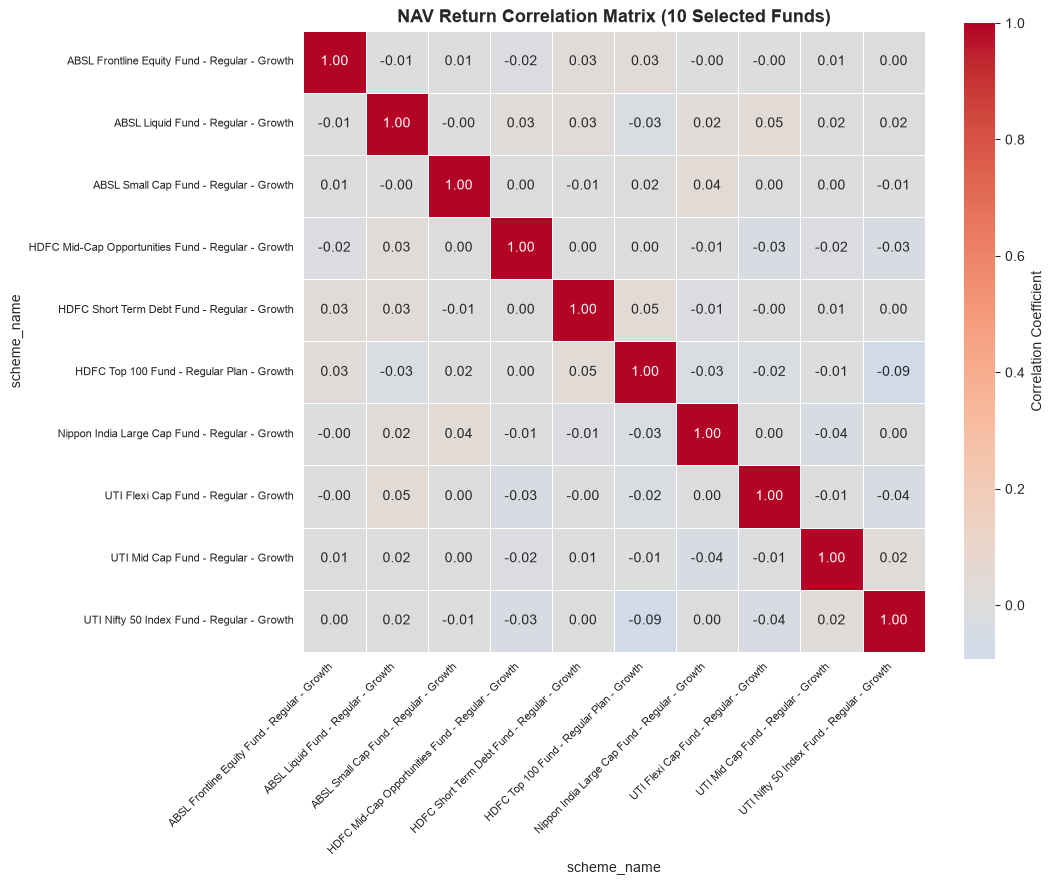

In [23]:
correlation_matrix = returns.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('NAV Return Correlation Matrix (10 Selected Funds)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../reports/charts/08_correlation_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

### Insight 8: NAV Return Correlation
Daily return correlations across the 10 selected schemes are consistently weak (mostly between -0.09 and +0.05), which is lower than typically expected for real-world funds tracking similar market segments, suggesting the underlying NAV series in this dataset may be independently simulated rather than driven by a shared market factor.  
*Supporting chart: `08_correlation_matrix.png`*

In [24]:
print(portfolio_holdings.head())
print()
print("Unique sectors:", portfolio_holdings['sector'].nunique())
print(portfolio_holdings['sector'].unique())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  

Unique sectors: 14
<StringArray>
[     'Utilities',        'Banking',    'Diversified',         'Pharma',
         'Paints',        'Telecom',             'IT',     'Automobile',
         

In [25]:
# Merge to bring in category info
holdings_with_category = portfolio_holdings.merge(
    fund_master[['amfi_code', 'category']],
    on='amfi_code',
    how='left'
)

# Filter to only Equity category funds
equity_holdings = holdings_with_category[holdings_with_category['category'] == 'Equity']

# Aggregate: average sector weight across all equity funds
sector_weights = equity_holdings.groupby('sector')['weight_pct'].mean().sort_values(ascending=False)

print(sector_weights)

sector
Consumer Goods    14.178889
Diversified       12.087857
IT                11.386750
Utilities         11.064167
FMCG              10.910000
Banking           10.871000
NBFC              10.826364
Pharma            10.722368
Automobile         9.807576
Telecom            9.708000
Energy             9.070000
Paints             8.986000
Cement             8.752500
Infrastructure     8.734545
Name: weight_pct, dtype: float64


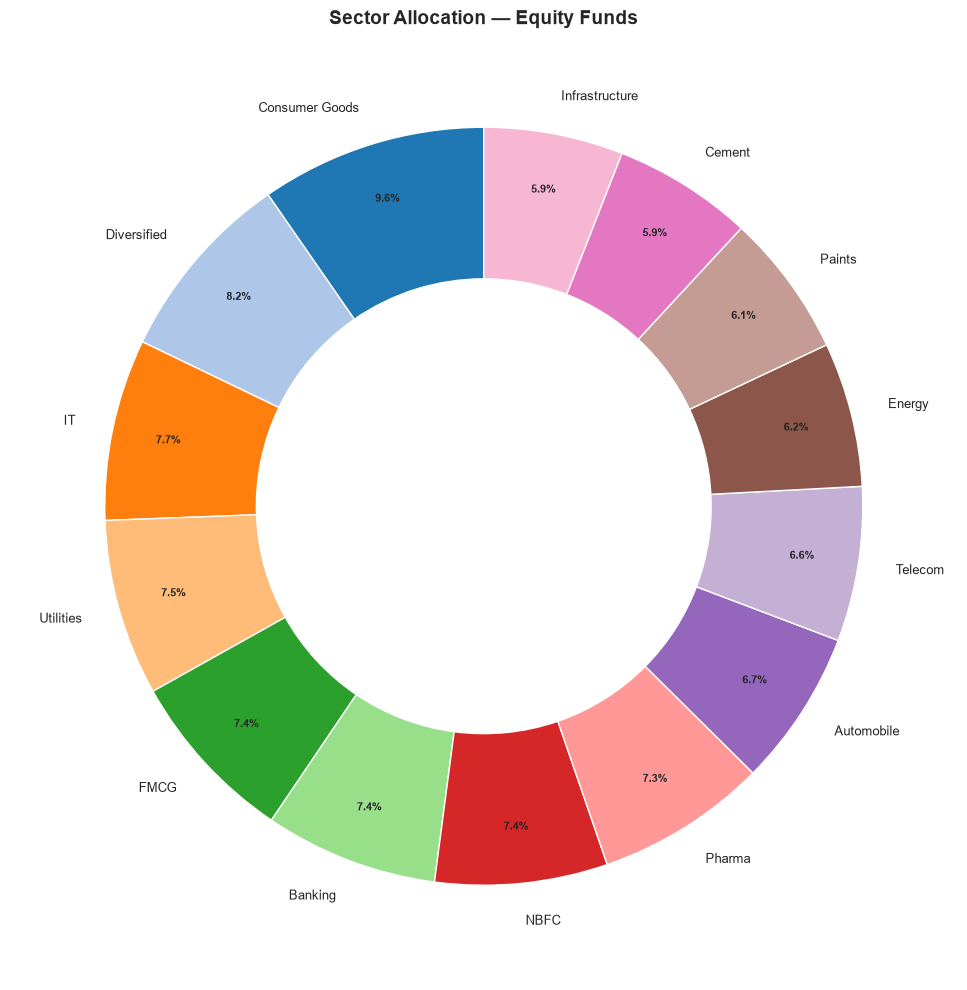

In [26]:
plt.figure(figsize=(10, 10))

colors = sns.color_palette('tab20', len(sector_weights))

wedges, texts, autotexts = plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    wedgeprops=dict(width=0.4, edgecolor='white')
)

plt.setp(autotexts, size=8, weight='bold')
plt.setp(texts, size=9)

plt.title('Sector Allocation — Equity Funds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/charts/09_sector_allocation_donut.png', dpi=200, bbox_inches='tight')
plt.show()

### Insight 1: NAV Trend Analysis
Equity fund NAVs show sustained growth through the 2023 bull run, with mid-cap and small-cap schemes posting the steepest gains, while the 2024 correction period shows a visible but temporary flattening across most equity schemes before resuming their upward trajectory into 2026.  
*Supporting chart: `01_nav_trend.png`*